<a href="https://colab.research.google.com/github/KarthikSwamy129/ThyroidCancerReoccurancePrediction/blob/main/ThyroidCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
df = pd.read_csv('/content/dataset.csv')
print(df.shape)
df.head()

(383, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [4]:

df.columns = df.columns.str.strip()


df['Recurred'] = df['Recurred'].map({'Yes': 1, 'No': 0})


print(df.isnull().sum())

df = df.dropna()

from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [5]:
X = df.drop('Recurred', axis=1)
y = df['Recurred']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        55
           1       0.95      0.86      0.90        22

    accuracy                           0.95        77
   macro avg       0.95      0.92      0.93        77
weighted avg       0.95      0.95      0.95        77

Confusion Matrix:
[[54  1]
 [ 3 19]]


ROC AUC Score: 0.9871900826446282


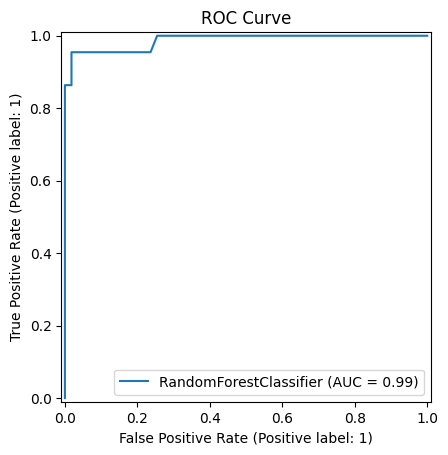

In [8]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print("ROC AUC Score:", roc_auc)

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

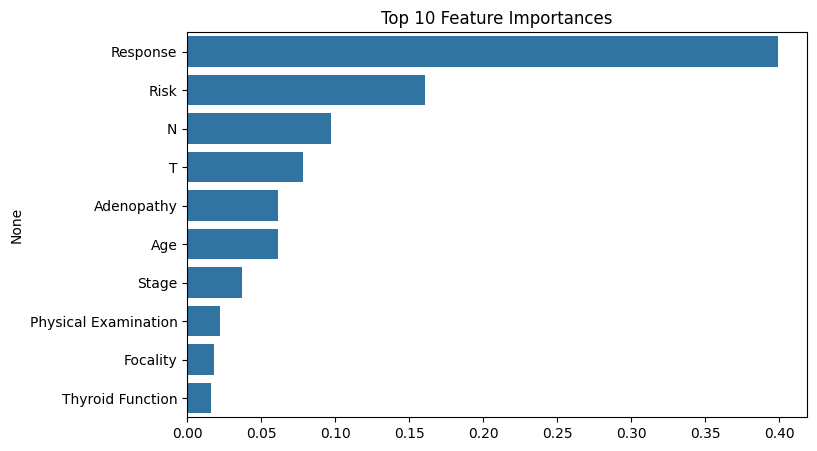

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
top = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top.values, y=top.index)
plt.title("Top 10 Feature Importances")
plt.show()

In [10]:
import joblib
joblib.dump(model, 'thyroid_recurrence_model.pkl')
print("Model saved as thyroid_recurrence_model.pkl")

Model saved as thyroid_recurrence_model.pkl


In [13]:


import joblib, pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder


MODEL_PATH = "thyroid_recurrence_model.pkl"
CSV_PATH   = "dataset.csv"

model = joblib.load(MODEL_PATH)
df_orig = pd.read_csv(CSV_PATH)
df_orig.columns = df_orig.columns.str.strip()


CAT_COLS = df_orig.select_dtypes(include="object").columns.drop("Recurred")
encoders = {c: LabelEncoder().fit(df_orig[c]) for c in CAT_COLS}


def ask(prompt, valid_options=None):
    while True:
        val = input(prompt).strip()
        if valid_options and val not in valid_options:
            print("  ❌  Invalid entry. Choose from:", valid_options)
            continue
        return val


def collect_user_input():
    print("\n===== Thyroid Cancer Recurrence Predictor =====\n")
    data = {}

    data["Age"] = int(ask("Enter Age: "))

    data["Gender"] = ask("Enter Gender (M/F): ", ["M", "F", "m", "f"]).upper()

    data["Smoking"] = ask("Current smoker? (Yes/No): ", ["Yes", "No", "yes", "no"]).capitalize()

    data["Hx Smoking"] = ask("Ever smoked? (Yes/No): ", ["Yes", "No", "yes", "no"]).capitalize()


    data["Hx Radiothreapy"] = ask("History of radiotherapy? (Yes/No): ", ["Yes", "No", "yes", "no"]).capitalize()

    data["Thyroid Function"] = ask(
        "Thyroid function (Euthyroid/Clinical Hyperthyroidism/Clinical Hypothyroidism/Subclinical Hyperthyroidism/Subclinical Hypothyroidism): ",
        ["Euthyroid", "Clinical Hyperthyroidism", "Clinical Hypothyroidism",
         "Subclinical Hyperthyroidism", "Subclinical Hypothyroidism"]
    )

    data["Physical Examination"] = ask(
        "Physical examination (Normal/Single nodular goiter-left/Single nodular goiter-right/Multinodular goiter/Diffuse goiter): ",
        ["Normal", "Single nodular goiter-left", "Single nodular goiter-right",
         "Multinodular goiter", "Diffuse goiter"]
    )

    data["Adenopathy"] = ask("Adenopathy (No/Right/Left/Bilateral/Extensive/Posterior): ",
                             ["No", "Right", "Left", "Bilateral", "Extensive", "Posterior"])

    data["Pathology"] = ask(
        "Pathology (Micropapillary/Papillary/Follicular/Hurthel cell): ",
        ["Micropapillary", "Papillary", "Follicular", "Hurthel cell"]
    )

    data["Focality"] = ask("Focality (Uni-Focal/Multi-Focal): ", ["Uni-Focal", "Multi-Focal"])

    data["Risk"] = ask("Risk (Low/Intermediate/High): ", ["Low", "Intermediate", "High"])

    data["T"] = ask("T stage (T1a/T1b/T2/T3a/T3b/T4a/T4b): ",
                    ["T1a", "T1b", "T2", "T3a", "T3b", "T4a", "T4b"])

    data["N"] = ask("N stage (N0/N1a/N1b): ", ["N0", "N1a", "N1b"])

    data["M"] = ask("M stage (M0/M1): ", ["M0", "M1"])

    data["Stage"] = ask("Stage (I/II/III/IVA/IVB): ", ["I", "II", "III", "IVA", "IVB"])

    data["Response"] = ask(
        "Response to treatment (Excellent/Indeterminate/Biochemical Incomplete/Structural Incomplete): ",
        ["Excellent", "Indeterminate", "Biochemical Incomplete", "Structural Incomplete"]
    )

    return pd.DataFrame([data])


def predict_recurrence():
    user_df = collect_user_input()


    for col in CAT_COLS:
        user_df[col] = encoders[col].transform(user_df[col])

    proba = model.predict_proba(user_df)[0, 1]
    pred = int(proba >= 0.5)

    print("\n===== Prediction Result =====")
    print(f"Recurrence probability: {proba:.2%}")
    print(f"Predicted class: {'Yes (Cancer)' if pred else 'No (No cancer)'}")
    print("=============================\n")


if __name__ == "__main__":
    predict_recurrence()


===== Thyroid Cancer Recurrence Predictor =====

Enter Age: 45
Enter Gender (M/F): M
Current smoker? (Yes/No): Yes
Ever smoked? (Yes/No): Yes
History of radiotherapy? (Yes/No): Yes
Thyroid function (Euthyroid/Clinical Hyperthyroidism/Clinical Hypothyroidism/Subclinical Hyperthyroidism/Subclinical Hypothyroidism): Clinical Hypothyroidism
Physical examination (Normal/Single nodular goiter-left/Single nodular goiter-right/Multinodular goiter/Diffuse goiter): Multinodular goiter
Adenopathy (No/Right/Left/Bilateral/Extensive/Posterior): Posterior
Pathology (Micropapillary/Papillary/Follicular/Hurthel cell): Papillary
Focality (Uni-Focal/Multi-Focal): Uni-Focal
Risk (Low/Intermediate/High): High
T stage (T1a/T1b/T2/T3a/T3b/T4a/T4b): T4b
N stage (N0/N1a/N1b): N1b
M stage (M0/M1): M0
Stage (I/II/III/IVA/IVB): IVB
Response to treatment (Excellent/Indeterminate/Biochemical Incomplete/Structural Incomplete): Biochemical Incomplete

===== Prediction Result =====
Recurrence probability: 75.00%
Pre